In [95]:
import numpy as np
import pandas as pd

In [96]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [97]:
print(f"Data size = {df.shape[0]:,} x {df.shape[1]}")

Data size = 37,249 x 2


In [98]:
df.sample()['clean_comment'].values

array(['hey this great effort and even better article had query though its basically the legality the current internet shutdown major cities gujarat ahmedabad surat the steps taken right now are for maintaining law and order and the directions basically come from local police which are abided the telecos out fear some institutional backlash something similar was done vadodara year ago this starting become thing the query however isn this legal loophole such shutdown isn covered any act perse and powers are only given central government are there are any regulatory measures all '],
      dtype=object)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [100]:
# df.isnull().sum() # total 100 null values
# df.duplicated().sum() # total 449 null values
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [101]:
df[(df['clean_comment'].str.strip() == "")]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [102]:
df = df[~(df['clean_comment'].str.strip() == "")]

In [103]:
# convert the 'clean_comment' to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [104]:
# Remove trailing and leading whitespaces from the 'clean_comment' column
df[df['clean_comment'].fillna('') != df['clean_comment'].fillna('').str.strip()]
df['clean_comment'] = df['clean_comment'].str.strip()
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [105]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()

,clean_comment,category


In [106]:
# Identify comments containing new line characters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

# Display the comments containing new line characters
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [107]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


## EDA

<Axes: xlabel='category', ylabel='count'>

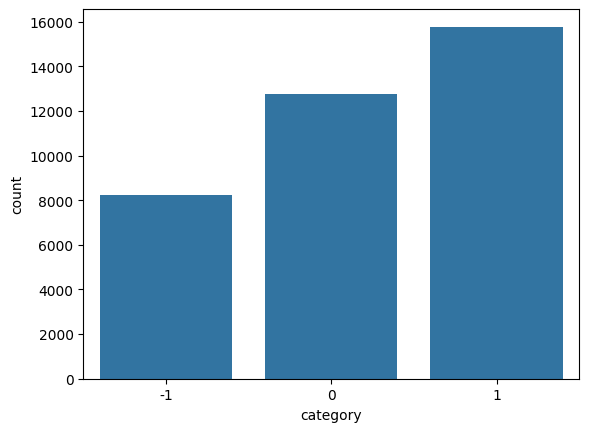

In [108]:

import seaborn as sns
import matplotlib.pyplot as plt
# distribution of classes

sns.countplot(data=df,x="category")

In [109]:
# frequency distribution of sentiments

df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [110]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [111]:
df.sample(5)

,clean_comment,category,word_count
29068,handover time changed 9pm ndtv india watching ...,1,8
30353,lol first let the basics kicking stalin dmk an...,1,14
1884,can mad that just good goal,1,6
28572,ani combat terror outfits operating your soil ...,0,9
25221,what gas doesn explain all,0,5


In [112]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

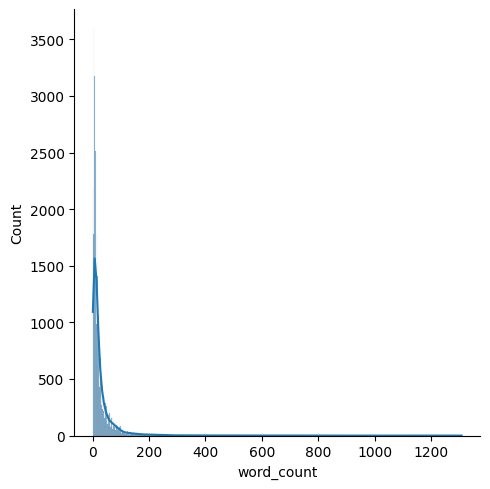

In [113]:
sns.displot(df['word_count'], kde=True)

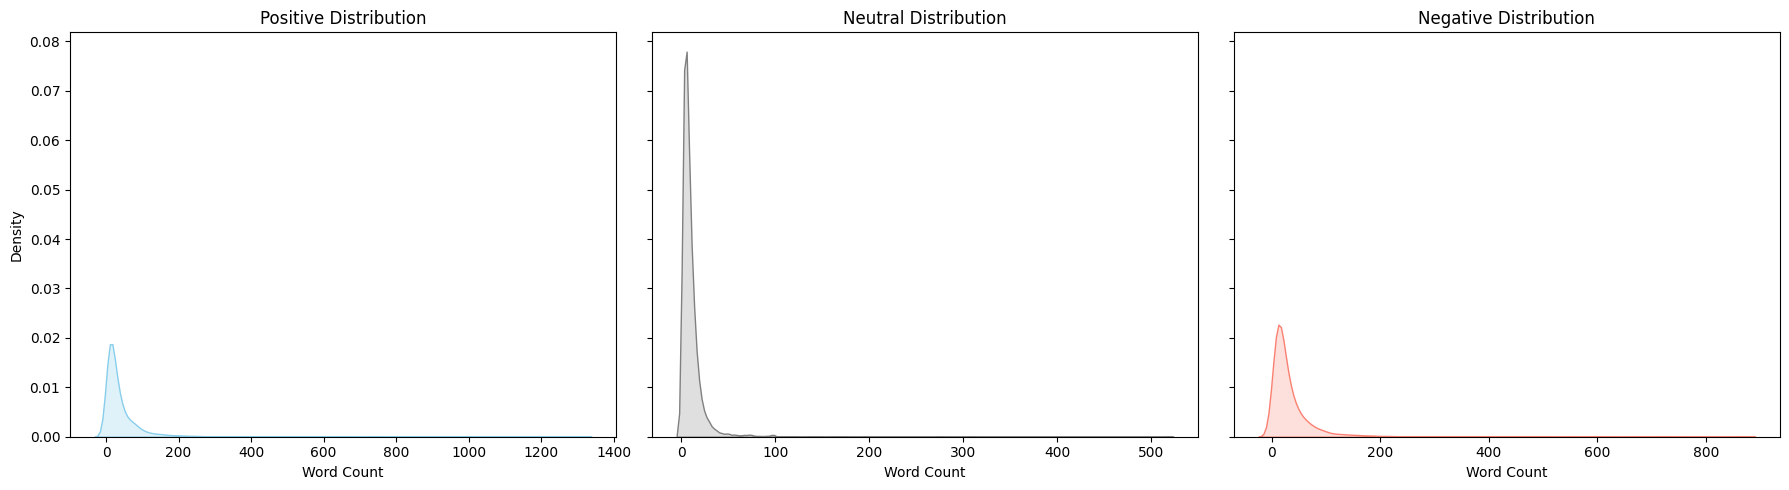

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

categories = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}
colors = {1: 'skyblue', 0: 'gray', -1: 'salmon'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (cat_val, cat_name) in enumerate(categories.items()):
    sns.kdeplot(
        data=df[df['category'] == cat_val], 
        x='word_count', 
        fill=True, 
        ax=axes[i], 
        color=colors[cat_val]
    )
    axes[i].set_title(f'{cat_name} Distribution')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Density' if i == 0 else "") # Only label the first Y-axis

plt.tight_layout()
plt.show()

Positive (1): High engagement with the widest spread, showing users love to write long, detailed praise.

Neutral (0): Short and sweet, with a tight concentration on low word counts and minimal elaboration.

Negative (-1): Vocal and expressive like positive comments, but usually more concise and to the point.

In [115]:
# Calculate num of stop words from list
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [116]:
stop_words = set(stopwords.words('english'))
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

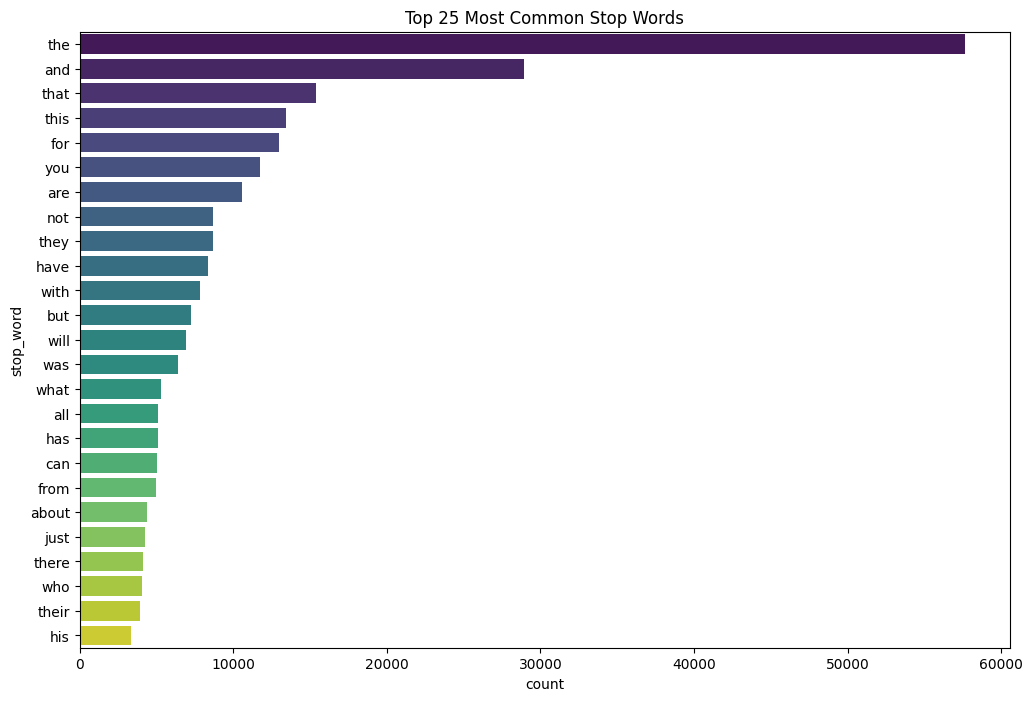

In [117]:
from collections import Counter
from itertools import chain

# 1. Use chain to flatten the split words and filter in one pass
# This is significantly faster for large DataFrames
word_gen = (word for comment in df['clean_comment'] for word in str(comment).split())
stop_word_freq = Counter(word for word in word_gen if word in stop_words)

# 2. Extract Top 25 and plot
top_25_df = pd.DataFrame(stop_word_freq.most_common(25), columns=['stop_word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', hue='stop_word', palette='viridis', legend=False)
plt.title('Top 25 Most Common Stop Words')
plt.show()

In [118]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [119]:
# Convert the character frequency into a DataFrame for better display
from collections import Counter
all_text = ''.join(df['clean_comment'])

char_freq = Counter(all_text)

char_frequency_df = pd.DataFrame(
    char_freq.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)


In [120]:
char_frequency_df.tail(10)

,character,frequency
840,贫,1
843,压,1
776,坚,1
778,取,1
779,己,1
786,示,1
792,删,1
793,呗,1
794,ഥ,1
795,杨,1


In [121]:
# remove them
df['clean_comment'] = df['clean_comment'].str.replace(r'[^\x00-\x7f]', '', regex=True)

In [122]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
22513,awesome list could clarify that baldur said kr...,1,26,10,140,0
11268,nice analysis have true sucks balls that have ...,1,49,19,266,0
27100,the prospect cleaning the numerous misundersta...,1,12,3,100,0
29754,could have put spoiler warning here,0,6,2,35,0
19320,hope dont need that ignorant chauvinist ideolo...,0,9,1,60,0


In [123]:
df['num_punctuation_chars'].value_counts()

num_punctuation_chars
0    36793
Name: count, dtype: int64

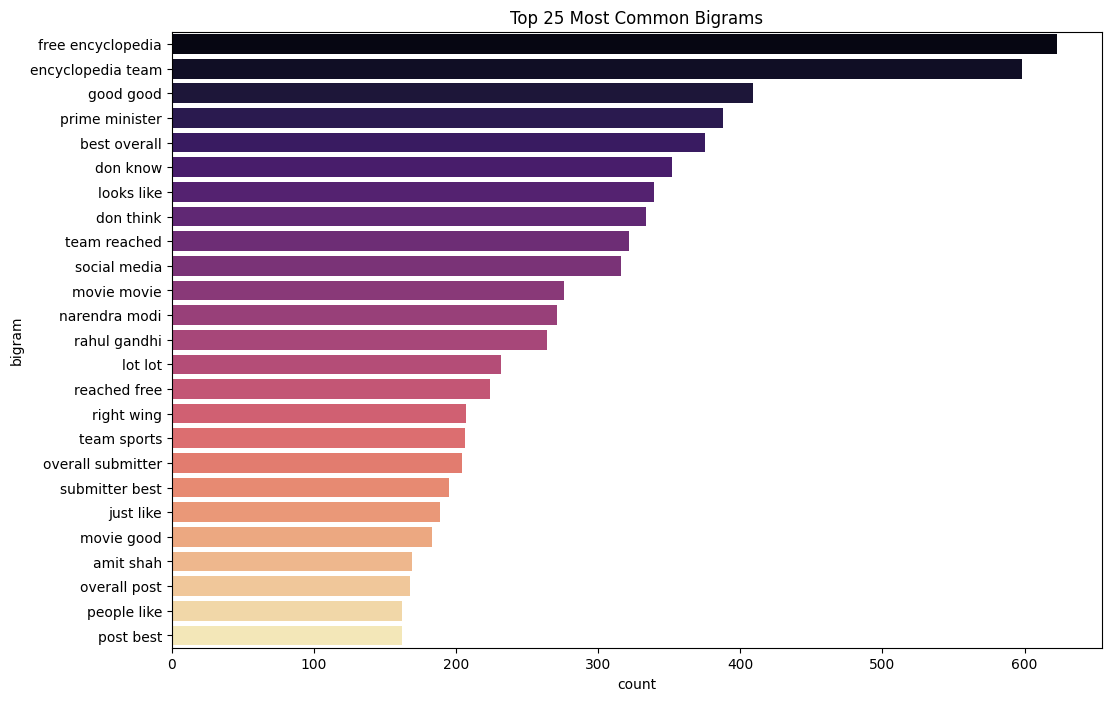

In [124]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_top_ngrams_optimized(corpus, n=25):
    # 1. Using a sparse matrix is efficient, but we want to sum counts immediately
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    # 2. Sum the counts for each bigram across all rows
    sum_words = bag_of_words.sum(axis=0).A1  # .A1 flattens the matrix to a 1D array
    
    # 3. Get feature names and map them to their counts
    feature_names = vec.get_feature_names_out()
    
    # 4. Use argsort to find the indices of the top N counts (way faster than sorting tuples)
    top_indices = np.argsort(sum_words)[-n:][::-1]
    
    return [(feature_names[i], sum_words[i]) for i in top_indices]

# Execution
top_25_bigrams = get_top_ngrams_optimized(df['clean_comment'], 25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plotting with hue to avoid warnings
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', hue='bigram', palette='magma', legend=False)
plt.title('Top 25 Most Common Bigrams')
plt.show()

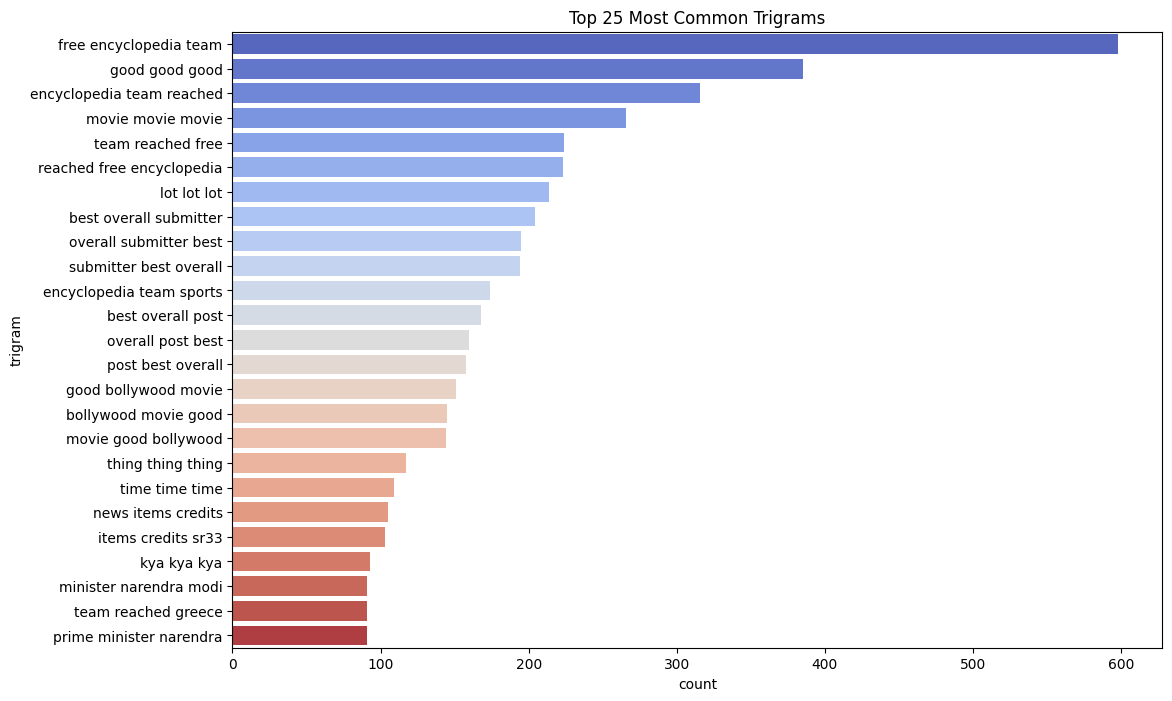

In [125]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_top_trigrams_optimized(corpus, n=25):
    # 1. Fit and transform in one go to save a bit of overhead
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    # 2. Sum counts and flatten to a 1D array using .A1
    sum_words = bag_of_words.sum(axis=0).A1
    
    # 3. Get the vocabulary names
    feature_names = vec.get_feature_names_out()
    
    # 4. Use NumPy's argsort for high-speed indexing of the top N
    top_indices = np.argsort(sum_words)[-n:][::-1]
    
    return [(feature_names[i], sum_words[i]) for i in top_indices]

# Execution
top_25_trigrams = get_top_trigrams_optimized(df['clean_comment'], 25)
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_25_trigrams_df, 
    x='count', 
    y='trigram', 
    hue='trigram', 
    palette='coolwarm', 
    legend=False
)
plt.title('Top 25 Most Common Trigrams')
plt.show()

In [126]:
# Remove stop words from 'clean_comment' column, retaining essential ones
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [127]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


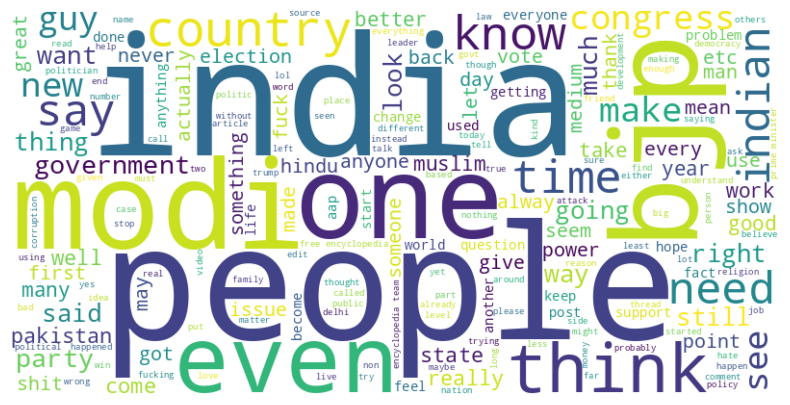

In [128]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

In [133]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_all_word_clouds(df):
    categories = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}
    colors = {1: 'Greens', 0: 'Greys', -1: 'Reds'} 
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    for i, (cat_val, cat_name) in enumerate(categories.items()):
        # 1. Grab the text and join it (handling potential NaNs with astype(str))
        text = " ".join(df[df['category'] == cat_val]['clean_comment'].astype(str))
        
        # 2. Generate the cloud (adding colormap for better visual distinction)
        wc = WordCloud(
            width=600, 
            height=400, 
            background_color='white',
            colormap=colors[cat_val]
        ).generate(text)
        
        # 3. Plotting on the specific subplot axis
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'{cat_name} Sentiment', fontsize=25)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

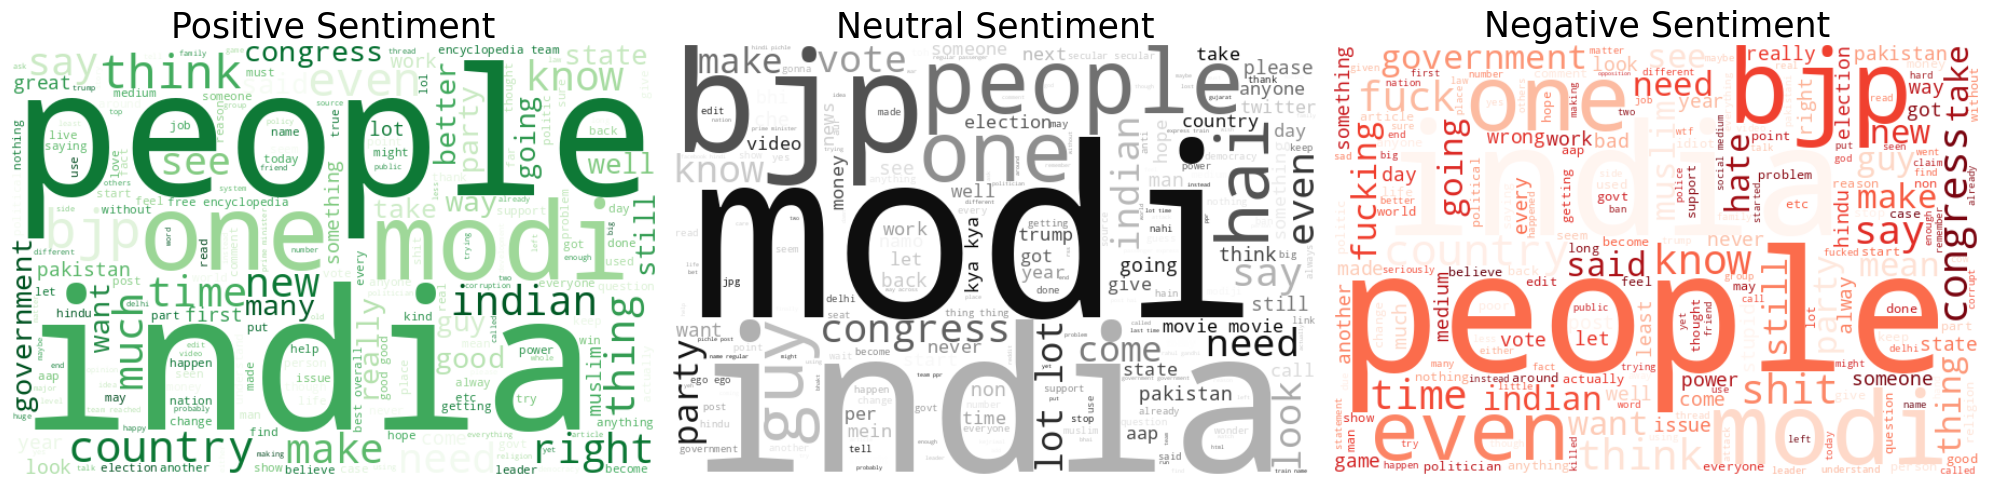

In [134]:
plot_all_word_clouds(df)

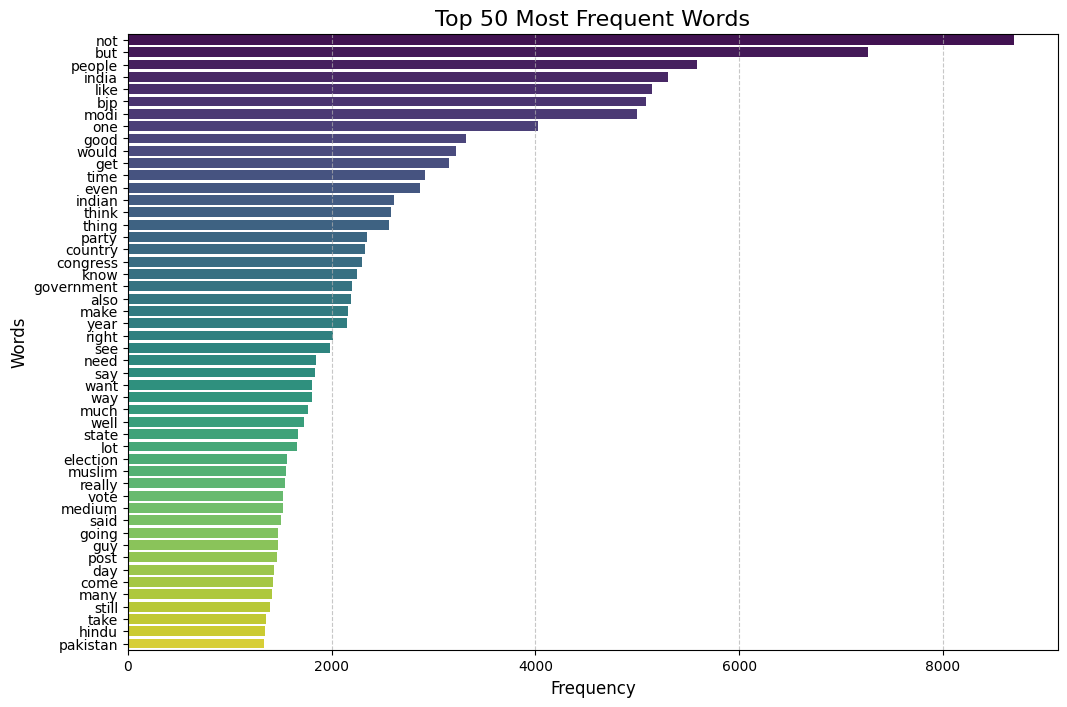

In [135]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_n_words_optimized(df, n=20):
    # 1. Use a generator to stream words - no massive string in memory!
    # We use str(comment) just in case there are any sneaky NaN values.
    word_gen = (word for comment in df['clean_comment'] for word in str(comment).split())
    
    # 2. Let Counter do the heavy lifting directly from the stream
    counter = Counter(word_gen)
    most_common_data = counter.most_common(n)

    # 3. Quickly convert to a DataFrame for Seaborn
    top_words_df = pd.DataFrame(most_common_data, columns=['word', 'count'])

    # 4. Plotting with modern Seaborn styling
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_words_df, 
        x='count', 
        y='word', 
        hue='word', 
        palette='viridis', 
        legend=False
    )
    
    plt.title(f'Top {n} Most Frequent Words', fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Words', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a subtle grid for readability
    plt.show()

# Run it for the top 50
plot_top_n_words_optimized(df, n=50)